
# Bayesian Analysis

In [4]:
from preprocessing.pipeline import preprocess_all

from frequentist.models import VAR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.var_model import VAR as smVAR
from statsmodels.graphics.tsaplots import plot_acf
from numpy.linalg import inv


## Preprocess

In [5]:
artifacts = preprocess_all(
    data_path="../data/complete_dataset.csv",
    date_col="date",
    start="1996-01-01",
    end="2023-11-30",
    select_cols=[
        "date",
        "global_EUI_GDP_weighted", "GPR", "cpu_index",
        "Europe Brent Spot Price FOB (Dollars per Barrel)"
    ],
    rename_map={
        "global_EUI_GDP_weighted": "eui",
        "GPR": "gpr",
        "cpu_index": "cpu",
        "Europe Brent Spot Price FOB (Dollars per Barrel)": "oil_price",
    },
    log_cols=["eui", "gpr", "cpu", "oil_price"],  # keeps log_<col>
    diff_cols=["eui", "gpr", "cpu", "oil_price"],  # makes d_<col> and dlog_<col>
    add_event_flags=True,
    train_ratio=0.8,
    save=False,
    save_path=None,
    visualize_flags=False,
)

features_df = artifacts["features_df"]
train_df = artifacts["train_df"]
test_df = artifacts["test_df"]

target_col = "log_eui"


[Info] Missing values by column:
global_EUI_equally_weighted                         128
global_EUI_GDP_weighted                             128
GPR                                                 106
SHARE_GPR                                           106
N10                                                 106
GPRC_ARG                                            106
GPRC_AUS                                            106
GPRC_BEL                                            106
GPRC_BRA                                            106
GPRC_CAN                                            106
GPRC_CHE                                            106
GPRC_CHL                                            106
GPRC_CHN                                            106
GPRC_COL                                            106
GPRC_DEU                                            106
GPRC_DNK                                            106
GPRC_EGY                                            106
GPRC_ESP      

## VAR(2) vs BVAR

## VAR(2)

In [6]:
# -----------------------------
# VAR(p = 2) - Manual choice
# -----------------------------

# Endogenous variables in LOG LEVELS (same as in VAR - Best)
var_endog_cols = ["log_eui", "log_gpr", "log_cpu", "log_oil_price"]

# TRAIN and TEST endogenous matrices
endog_train_var = train_df[var_endog_cols].dropna()
endog_test_var  = test_df[var_endog_cols]

# Combined full sample (needed for expanding window)
endog_full = pd.concat([train_df[var_endog_cols], test_df[var_endog_cols]])

# -----------------------------
# 1. Set manual lag order
# -----------------------------
manual_lag_var = 2
print(f"Manual VAR lag order p = {manual_lag_var}")

# -----------------------------
# 2. Fit VAR(p=2) on entire TRAIN sample
# -----------------------------
var_p2_model_train = VAR(endog_train_var)
var_p2_res_train   = var_p2_model_train.fit(manual_lag_var)
print(var_p2_res_train.summary())

Manual VAR lag order p = 2
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 14, Apr, 2026
Time:                     10:29:47
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -10.7759
Nobs:                     266.000    HQIC:                  -11.0661
Log likelihood:           23.9521    FPE:                1.28673e-05
AIC:                     -11.2609    Det(Omega_mle):     1.12638e-05
--------------------------------------------------------------------
Results for equation log_eui
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                   -1.574810         0.609967           -2.582           0.010
L1.log_eui               0.418378         0.060513            6.914           0.000
L1.log_gpr         

C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Residuals

In [7]:
# In-sample fitted log_eui
var_p2_fitted_log = var_p2_res_train.fittedvalues["log_eui"]

# In-sample residuals in log-level space
actual_log_train = endog_train_var.loc[var_p2_fitted_log.index, "log_eui"]
var_p2_resid_in  = (actual_log_train - var_p2_fitted_log).dropna()
var_p2_resid_in.name = "var_p2_resid_in"

print("\nVAR(p=2) — in-sample residuals (log space, head):")
print(var_p2_resid_in.head())


VAR(p=2) — in-sample residuals (log space, head):
date
1996-03-01   -0.694873
1996-04-01    0.040702
1996-05-01    0.806072
1996-06-01   -1.690263
1996-07-01    0.506826
Name: var_p2_resid_in, dtype: float64


#### Forecast

In [8]:
# -----------------------------
# 3. Expanding-window 1-step-ahead forecasts with VAR(p=2)
# -----------------------------
test_index = test_df.index
n_train    = len(train_df)
var_p2_log_eui_fcast = []

for i, current_date in enumerate(test_index):
    # Window up to t-1 in the full sample
    end_train_idx = n_train + i
    endog_train_i = endog_full.iloc[:end_train_idx].dropna()

    # Fit VAR(p=2) on this window
    var_p2_model_i = VAR(endog_train_i)
    var_p2_res_i   = var_p2_model_i.fit(manual_lag_var)

    # Last p observations as starting history
    y_history = endog_train_i.values[-manual_lag_var:]

    # 1-step-ahead forecast (no exogenous variables)
    fcast_i = var_p2_res_i.forecast(y=y_history, steps=1)

    # Extract log_eui forecast (log-level)
    log_eui_idx = endog_train_i.columns.get_loc("log_eui")
    log_eui_hat = fcast_i[0, log_eui_idx]
    var_p2_log_eui_fcast.append(log_eui_hat)

# Convert to Series aligned with TEST index
var_p2_log_eui_forecast = pd.Series(
    var_p2_log_eui_fcast,
    index=test_index,
    name="var_p2_log_eui_forecast",
)

print("\nVAR(p=2) — 1-step-ahead forecasts (log_eui level, head):")
print(var_p2_log_eui_forecast.head())

# -----------------------------
# 4. Out-of-sample forecast errors (log space)
# -----------------------------
actual_log_eui_test = test_df.loc[test_index, "log_eui"]
var_p2_resid_oos = (actual_log_eui_test - var_p2_log_eui_forecast).dropna()
var_p2_resid_oos.name = "var_p2_resid_oos"

print("\nVAR(p=2) — out-of-sample forecast errors (log space, head):")
print(var_p2_resid_oos.head())

C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so infe


VAR(p=2) — 1-step-ahead forecasts (log_eui level, head):
date
2018-05-01    0.031923
2018-06-01    0.031072
2018-07-01    0.083297
2018-08-01    0.240623
2018-09-01    0.155608
Name: var_p2_log_eui_forecast, dtype: float64

VAR(p=2) — out-of-sample forecast errors (log space, head):
date
2018-05-01   -0.172383
2018-06-01    0.097868
2018-07-01    0.075669
2018-08-01   -0.113764
2018-09-01   -0.084709
Name: var_p2_resid_oos, dtype: float64


C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## BVAR

In [20]:
var_select = smVAR(train_df[["log_eui","log_gpr","log_cpu","log_oil_price"]])
results = var_select.select_order(maxlags=12)
print(results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -5.596      -5.541    0.003712      -5.574
1       -11.19     -10.92*   1.376e-05      -11.08
2       -11.27      -10.77   1.272e-05      -11.07
3       -11.42      -10.70   1.100e-05     -11.13*
4       -11.38      -10.44   1.143e-05      -11.00
5       -11.43      -10.27   1.090e-05      -10.96
6       -11.42      -10.03   1.102e-05      -10.86
7      -11.43*      -9.827  1.087e-05*      -10.79
8       -11.37      -9.541   1.162e-05      -10.63
9       -11.30      -9.251   1.247e-05      -10.48
10      -11.27      -9.004   1.283e-05      -10.36
11      -11.30      -8.803   1.261e-05      -10.29
12      -11.35      -8.639   1.196e-05      -10.26
--------------------------------------------------


C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [21]:
def build_X_matrix(data, p):
    """Build the stacked regressor matrix X and response Y for VAR(p)."""
    T_full, n = data.shape
    T = T_full - p
    Y = data[p:]                          # (T, n)
    X = np.hstack([
        np.ones((T, 1)),                  # intercept
        *[data[p-l-1:T_full-l-1] for l in range(p)]
    ])                                     # (T, 1 + n*p)
    return Y, X

def draw_beta(Y, X, Sigma, beta_0, V_beta_inv):
    """Draw β from its full conditional Normal distribution (Chapter 5)."""
    T, n = Y.shape
    k = X.shape[1]
    Sigma_inv = inv(Sigma)
    # Kβ = Vβ⁻¹ + X'(I⊗Σ⁻¹)X  — in the stacked regression this simplifies to:
    K_beta = V_beta_inv + np.kron(Sigma_inv, X.T @ X)
    K_beta_inv = inv(K_beta)
    y_vec = Y.T.flatten()                  # vec(Y), shape (n*T,)
    X_kron = np.kron(np.eye(n), X)         # (n*T, n*k)
    rhs = V_beta_inv @ beta_0 + X_kron.T @ np.kron(Sigma_inv, np.eye(T)) @ y_vec
    beta_mean = K_beta_inv @ rhs
    beta_draw = np.random.multivariate_normal(beta_mean, K_beta_inv)
    return beta_draw

def draw_Sigma(Y, X, beta, nu_0, S_0):
    """Draw Σ from its full conditional Inverse-Wishart distribution (Chapter 5)."""
    T, n = Y.shape
    k = X.shape[1]
    B = beta.reshape(k, n, order='F')      # reshape to (k, n) coefficient matrix
    resid = Y - X @ B                      # (T, n)
    S_post = S_0 + resid.T @ resid
    nu_post = nu_0 + T
    # Draw from IW(nu_post, S_post): if W ~ Wishart then Sigma = W^{-1}
    Sigma_draw = inv(np.random.multivariate_normal(
        np.zeros(n), inv(S_post), size=nu_post).T
        @ np.random.multivariate_normal(np.zeros(n), inv(S_post), size=nu_post))
    # Cleaner: use scipy
    from scipy.stats import wishart
    W = wishart.rvs(df=nu_post, scale=inv(S_post))
    return inv(W)

def run_bvar_gibbs(Y, X, beta_0, V_beta, nu_0, S_0,
                   n_iter=5000, n_burnin=1000):
    """
    Gibbs sampler for BVAR following Chapter 5 of the course notes.
    Returns posterior draws of beta and Sigma after burn-in.
    """
    n = Y.shape[1]
    k = X.shape[1]
    V_beta_inv = inv(V_beta)

    # Initialise with OLS estimate
    B_ols = inv(X.T @ X) @ X.T @ Y
    beta_curr = B_ols.flatten(order='F')
    resid_ols = Y - X @ B_ols
    Sigma_curr = (resid_ols.T @ resid_ols) / len(Y)

    beta_draws = []
    Sigma_draws = []

    for i in range(n_iter):
        # Step 1: draw beta | Sigma, y
        beta_curr = draw_beta(Y, X, Sigma_curr, beta_0, V_beta_inv)
        # Step 2: draw Sigma | beta, y
        Sigma_curr = draw_Sigma(Y, X, beta_curr, nu_0, S_0)

        if i >= n_burnin:
            beta_draws.append(beta_curr.copy())
            Sigma_draws.append(Sigma_curr.copy())

    return np.array(beta_draws), np.array(Sigma_draws)

In [42]:
# -----------------------------------------------
# Minnesota Prior for BVAR(2)
# -----------------------------------------------
# Variables: [log_eui, log_gpr, log_cpu, log_oil_price]
# k = 9  (intercept + 4 vars × 2 lags)
# n = 4, p = 2

p = 2
n = 4
var_cols = ["log_eui", "log_gpr", "log_cpu", "log_oil_price"]

data_train = train_df[var_cols].values
Y, X = build_X_matrix(data_train, p)
k = X.shape[1]   # 9

# --- Fit frequentist VAR on training data to get residual std per equation ---
var_model_train = smVAR(train_df[var_cols])
var_fit = var_model_train.fit(maxlags=p, ic=None)
# sigma_i: in-sample residual std for each variable (used to scale prior)
sigma_vec = np.sqrt(np.diag(var_fit.sigma_u.values))   # shape (n,)

# --- Minnesota Prior hyperparameters ---
lambda1 = 0.2    # overall tightness  (smaller = more shrinkage; try 0.1–0.2)
lambda2 = 0.5    # cross-variable decay (relative to own-lag; try 0.5)
lambda3 = 1.0    # lag decay exponent (higher = faster shrinkage for higher lags)

# --- Build beta_0: random-walk prior on own first lag, zeros elsewhere ---
# Coefficient order (column-major / 'F' order as in your draw_beta):
# [const, eui_L1, gpr_L1, cpu_L1, oil_L1, eui_L2, gpr_L2, cpu_L2, oil_L2]  × n equations
# beta_0 vec(B) in 'F' order: for each equation j, then for each predictor i
beta_0 = np.zeros(n * k)

# Set the own-lag-1 coefficient to 1.0 for each equation
# In vec(B) with 'F' order: position for equation j, predictor i is j + n*i
for j in range(n):
    own_lag1_predictor_idx = 1 + j   # intercept at 0, then lag-1 vars start at 1
    flat_idx = j + n * own_lag1_predictor_idx
    beta_0[flat_idx] = 1.0           # random walk prior

# --- Build V_beta: Minnesota variance for each element of vec(B) ---
# For coefficient of variable i at lag l in equation j:
#   - own lag  (i == j): (lambda1 / l^lambda3)^2
#   - cross lag (i != j): (lambda1 * lambda2 * sigma_j / (l^lambda3 * sigma_i))^2
#   - intercept: large variance (diffuse)
V_beta_diag = np.zeros(n * k)

for j in range(n):           # equation index
    for i_pos in range(k):   # predictor index (0=intercept, 1..n=lag1, n+1..=lag2, ...)
        flat_idx = j + n * i_pos

        if i_pos == 0:
            # Intercept: keep diffuse
            V_beta_diag[flat_idx] = 10.0
        else:
            # Determine lag number and variable index
            lag = (i_pos - 1) // n + 1          # 1 or 2
            var_i = (i_pos - 1) % n             # which variable (0..3)

            if var_i == j:
                # Own-lag coefficient
                v = (lambda1 / lag**lambda3) ** 2
            else:
                # Cross-variable coefficient
                v = (lambda1 * lambda2 * sigma_vec[j] / (lag**lambda3 * sigma_vec[var_i])) ** 2

            V_beta_diag[flat_idx] = v

V_beta = np.diag(V_beta_diag)

# --- Prior on Sigma: use VAR residual covariance as scale matrix ---
# nu_0 > n+1 for proper prior; higher = more informative
# Use a tighter, more honest S_0
S_0  = var_fit.sigma_u.values.copy()   # no inflation factor
nu_0 = n + 2                           # keep minimal degrees of freedom

# --- Run Gibbs ---
beta_draws, Sigma_draws = run_bvar_gibbs(
    Y, X, beta_0, V_beta, nu_0, S_0,
    n_iter=6000, n_burnin=1000
)

print(f"Posterior beta shape:  {beta_draws.shape}")
print(f"Posterior Sigma shape: {Sigma_draws.shape}")

C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Posterior beta shape:  (5000, 36)
Posterior Sigma shape: (5000, 4, 4)


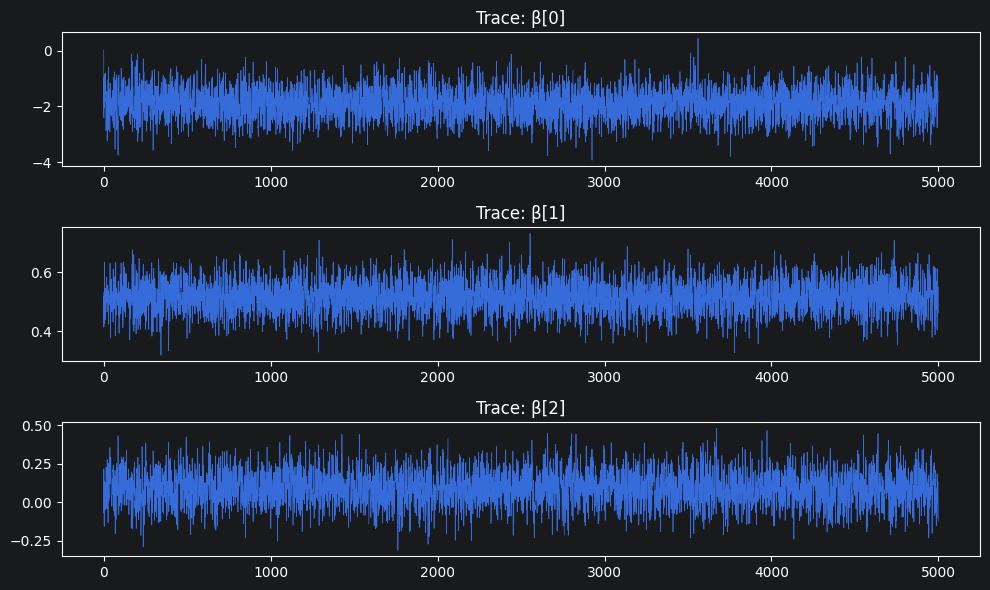

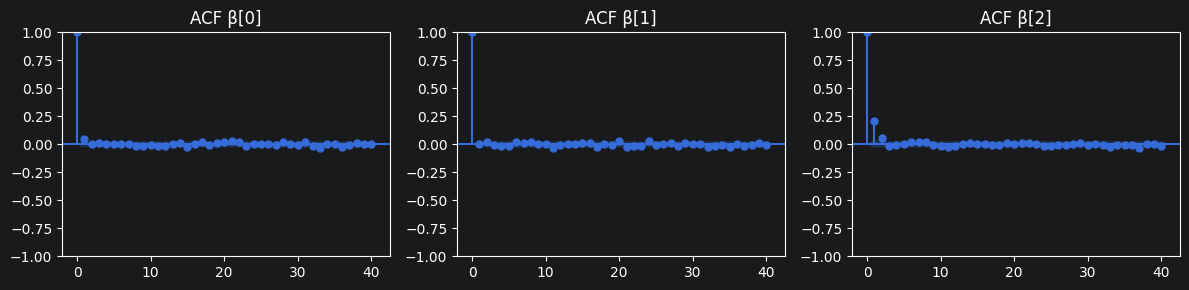

In [43]:
# Trace plot for first few beta coefficients
fig, axes = plt.subplots(3, 1, figsize=(10, 6))
for i, ax in enumerate(axes):
    ax.plot(beta_draws[:, i], lw=0.5)
    ax.set_title(f"Trace: β[{i}]")
plt.tight_layout()
plt.show()

# Autocorrelation of draws (visual inspection per Section 4.10.1)
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for i, ax in enumerate(axes):
    plot_acf(beta_draws[:, i], lags=40, ax=ax, title=f"ACF β[{i}]")
plt.tight_layout()
plt.show()

In [44]:
def bvar_predictive_draws(X_new, beta_draws, Sigma_draws):
    """
    Generate one predictive draw per posterior sample.
    For each (beta, Sigma) draw, sample y* ~ N(X_new @ B, Sigma).
    Returns array of shape (n_draws, n_vars).
    """
    n_vars = 4
    k = X_new.shape[0]
    pred_draws = []

    for beta_flat, Sigma in zip(beta_draws, Sigma_draws):
        B = beta_flat.reshape((k, n_vars), order='F')
        mu = X_new @ B                          # predictive mean: (n_vars,)
        y_draw = np.random.multivariate_normal(mu, Sigma)
        pred_draws.append(y_draw)

    return np.array(pred_draws)   # (n_draws, n_vars)

In [52]:
# -----------------------------------------------
# TRUE Expanding Window BVAR Forecast
# -----------------------------------------------

bvar_preds = []
bvar_stds  = []

full_data_np = endog_full.values  # shape (T_total, 4)
n_train      = len(train_df)
test_index   = test_df.index

print(f"Running TRUE expanding-window BVAR for {len(test_index)} steps...")

for i in range(len(test_index)):
    # --- 1. Expanding window: train + all observed test points so far ---
    current_end = n_train + i          # does NOT include the point we're predicting
    data_window = full_data_np[:current_end]   # grows by 1 each step

    # --- 2. Refit prior on this window ---
    var_fit_w   = smVAR(data_window).fit(maxlags=p, ic=None)
    sigma_vec_w = np.sqrt(np.diag(var_fit_w.sigma_u))

    # Rebuild Minnesota V_beta for this window
    V_beta_diag = np.zeros(n * k)
    for j in range(n):
        for i_pos in range(k):
            flat_idx = j + n * i_pos
            if i_pos == 0:
                V_beta_diag[flat_idx] = 10.0
            else:
                lag   = (i_pos - 1) // n + 1
                var_i = (i_pos - 1) % n
                if var_i == j:
                    v = (lambda1 / lag**lambda3) ** 2
                else:
                    v = (lambda1 * lambda2 * sigma_vec_w[j] / (lag**lambda3 * sigma_vec_w[var_i])) ** 2
                V_beta_diag[flat_idx] = v
    V_beta_w = np.diag(V_beta_diag)

    S_0_w  = var_fit_w.sigma_u.copy()
    nu_0_w = n + 2

    # --- 3. Build Y, X for this window and run Gibbs ---
    Y_w, X_w = build_X_matrix(data_window, p)

    beta_draws_w, Sigma_draws_w = run_bvar_gibbs(
        Y_w, X_w,
        beta_0   = np.zeros(n * k),
        V_beta   = V_beta_w,
        nu_0     = nu_0_w,
        S_0      = S_0_w,
        n_iter   = 3000,    # fewer iterations per step to keep runtime manageable
        n_burnin = 500,
    )

    # --- 4. Forecast the next point using actual lags ---
    lag1  = full_data_np[current_end - 1]
    lag2  = full_data_np[current_end - 2]
    X_new = np.concatenate([[1.0], lag1, lag2])

    pred_draws = bvar_predictive_draws(X_new, beta_draws_w, Sigma_draws_w)
    bvar_preds.append(pred_draws[:, 0].mean())
    bvar_stds.append(pred_draws[:, 0].std())

    if i % 10 == 0:
        print(f"  Step {i+1}/{len(test_index)} done")

# --- Results ---
bvar_forecast_series = pd.Series(bvar_preds, index=test_index, name="bvar_log_eui_forecast")
actual_log_eui_test  = test_df.loc[test_index, "log_eui"]
bvar_resid_oos       = actual_log_eui_test - bvar_forecast_series

rmse_bvar = np.sqrt(np.mean(bvar_resid_oos**2))
rmse_freq = np.sqrt(np.mean(var_p2_resid_oos**2))

print("\n=== OOS PERFORMANCE COMPARISON ===")
print(f"Frequentist VAR(2) RMSE: {rmse_freq:.6f}")
print(f"True Expanding BVAR RMSE: {rmse_bvar:.6f}")

Running TRUE expanding-window BVAR for 67 steps...
  Step 1/67 done
  Step 11/67 done
  Step 21/67 done
  Step 31/67 done
  Step 41/67 done
  Step 51/67 done
  Step 61/67 done

=== OOS PERFORMANCE COMPARISON ===
Frequentist VAR(2) RMSE: 0.270232
True Expanding BVAR RMSE: 0.271719


In [53]:
def crps_from_draws(predictive_draws, y_true):
    """
    Compute CRPS using the energy score representation.

    Parameters
    ----------
    predictive_draws : array of shape (M,)
        Draws from the predictive distribution for a scalar outcome.
    y_true : float
        The realised value.

    Returns
    -------
    float : CRPS value (lower is better)
    """
    M = len(predictive_draws)

    # First term: average absolute error against the truth
    term1 = np.mean(np.abs(predictive_draws - y_true))

    # Second term: average absolute difference between pairs of draws
    # Efficient computation using the identity: E|X-X'| = 2/M^2 * sum_{i<j} |x_i - x_j|
    sorted_draws = np.sort(predictive_draws)
    weights = 2 * np.arange(1, M + 1) - M - 1   # (2i - M - 1) for i=1..M
    term2 = np.dot(weights, sorted_draws) / (M ** 2)

    return term1 - term2

In [54]:
# Estimate residual variance from the frequentist VAR on the training set
# var_p2_resid_oos is already in your notebook
# For the frequentist, use in-sample residual std as the predictive std

# Fit the frequentist VAR on training data to get residual covariance
var_model_train = smVAR(train_df[var_cols])
var_fit = var_model_train.fit(maxlags=2, ic=None)
sigma_freq = np.sqrt(var_fit.sigma_u.iloc[0, 0])   # std for log_eui equation (index 0)

print(f"Frequentist VAR residual std for log_eui: {sigma_freq:.4f}")

Frequentist VAR residual std for log_eui: 0.5324


C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [55]:
# -----------------------------------------------
# CRPS: BVAR vs Frequentist VAR
# -----------------------------------------------

crps_bvar_list   = []
crps_freq_list   = []

eui_idx = 0   # log_eui is variable 0 in your ordering

for i in range(len(test_index)):
    current_loc = n_train + i
    lag1 = full_data_np[current_loc - 1]
    lag2 = full_data_np[current_loc - 2]
    X_new = np.concatenate([[1.0], lag1, lag2])

    # Realised value
    y_true = test_df.loc[test_index[i], "log_eui"]

    # --- BVAR predictive draws ---
    pred_draws_full = bvar_predictive_draws(X_new, beta_draws, Sigma_draws)
    pred_draws_eui  = pred_draws_full[:, eui_idx]   # log_eui draws only
    crps_bvar_list.append(crps_from_draws(pred_draws_eui, y_true))

    # --- Frequentist VAR "predictive distribution" ---
    # Point forecast from your existing series, approximate Gaussian around it
    freq_point = bvar_forecast_series.iloc[i]   # reuse existing freq point forecast
    # Note: replace with your VAR point forecast series if named differently
    freq_draws = np.random.normal(loc=freq_point, scale=sigma_freq, size=len(beta_draws))
    crps_freq_list.append(crps_from_draws(freq_draws, y_true))

crps_bvar_mean = np.mean(crps_bvar_list)
crps_freq_mean = np.mean(crps_freq_list)

print("\n=== PROBABILISTIC FORECAST EVALUATION (CRPS) ===")
print(f"Frequentist VAR(2) mean CRPS: {crps_freq_mean:.6f}")
print(f"Informed BVAR(2)   mean CRPS: {crps_bvar_mean:.6f}")
print(f"\nCRPS skill score (BVAR vs VAR): {1 - crps_bvar_mean/crps_freq_mean:.4f}")
print("(Positive skill = BVAR dominates)")


=== PROBABILISTIC FORECAST EVALUATION (CRPS) ===
Frequentist VAR(2) mean CRPS: 0.176298
Informed BVAR(2)   mean CRPS: 0.187977

CRPS skill score (BVAR vs VAR): -0.0662
(Positive skill = BVAR dominates)


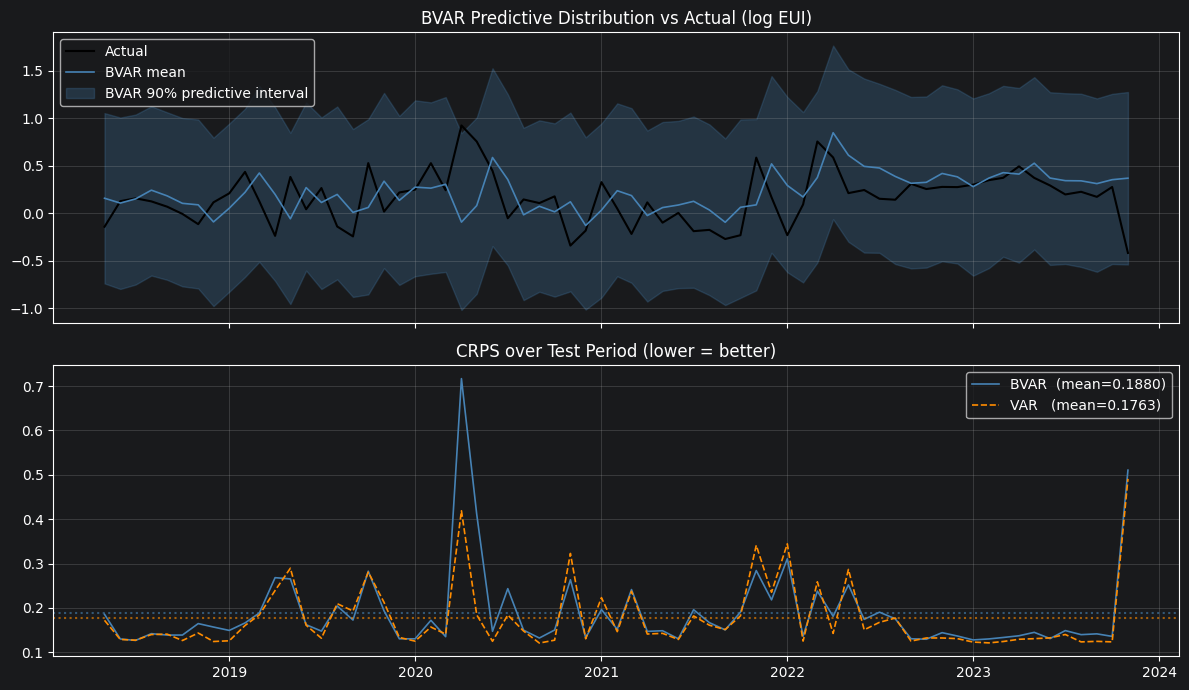

In [56]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top panel: point forecasts with BVAR uncertainty bands
pred_means = []
pred_lower = []
pred_upper = []

for i in range(len(test_index)):
    current_loc = n_train + i
    lag1 = full_data_np[current_loc - 1]
    lag2 = full_data_np[current_loc - 2]
    X_new = np.concatenate([[1.0], lag1, lag2])
    draws = bvar_predictive_draws(X_new, beta_draws, Sigma_draws)[:, eui_idx]
    pred_means.append(np.mean(draws))
    pred_lower.append(np.percentile(draws, 5))
    pred_upper.append(np.percentile(draws, 95))

axes[0].plot(test_index, test_df["log_eui"].values, label="Actual", color="black", lw=1.5)
axes[0].plot(test_index, pred_means, label="BVAR mean", color="steelblue", lw=1.2)
axes[0].fill_between(test_index, pred_lower, pred_upper,
                     alpha=0.25, color="steelblue", label="BVAR 90% predictive interval")
axes[0].set_title("BVAR Predictive Distribution vs Actual (log EUI)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom panel: CRPS over time
axes[1].plot(test_index, crps_bvar_list,  label=f"BVAR  (mean={crps_bvar_mean:.4f})",
             color="steelblue", lw=1.2)
axes[1].plot(test_index, crps_freq_list, label=f"VAR   (mean={crps_freq_mean:.4f})",
             color="darkorange", lw=1.2, linestyle="--")
axes[1].axhline(crps_bvar_mean,  color="steelblue",   linestyle=":", alpha=0.6)
axes[1].axhline(crps_freq_mean, color="darkorange", linestyle=":", alpha=0.6)
axes[1].set_title("CRPS over Test Period (lower = better)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()